In [1]:
import torch
import numpy as np
from torch import Tensor
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

from src.plotting import plt_sample
from src.configs import TrainingConfig, DatasetConfig, DEVICE
from src.dataset import get_data_loaders, load_preprocessed_dataset

In [2]:
from torchvision.transforms import v2

train_cfg = TrainingConfig(batch_size=10)
dataset_cfg = DatasetConfig(transform = v2.Compose([
        v2.RandomErasing(p=1, scale=(0.05, 0.1)),
        v2.RandomErasing(p=1, scale=(0.05, 0.1)),
        v2.RandomAffine(degrees=(0, 0), translate=(0.1, 0.3), scale=(0.75, 1)),
    ])
)
x_train, y_train, x_test = load_preprocessed_dataset()
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train,
    y_train,
    test_size=dataset_cfg.test_size,
    random_state=train_cfg.random_state,
)
train_loader, valid_loader = get_data_loaders(
    x_train,
    y_train,
    x_valid,
    y_valid,
    train_cfg=train_cfg,
    dataset_cfg=dataset_cfg,
    # transform=train_transform
)

In [3]:
batch_x, batch_y = next(iter(train_loader))

/root/repos/raidium_challenge/.venv/lib/python3.13/site-packages/torchvision/transforms/v2/_augment.py:94: UserWarning: RandomErasing() is currently passing through inputs of type tv_tensors.Mask. This will likely change in the future.
  warnings.warn(


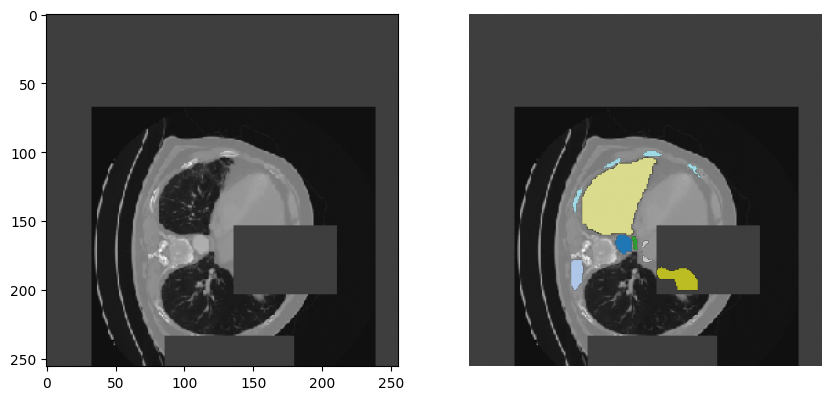

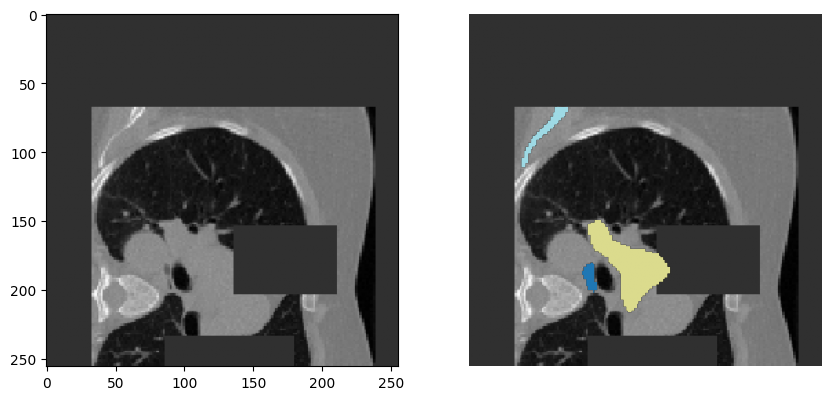

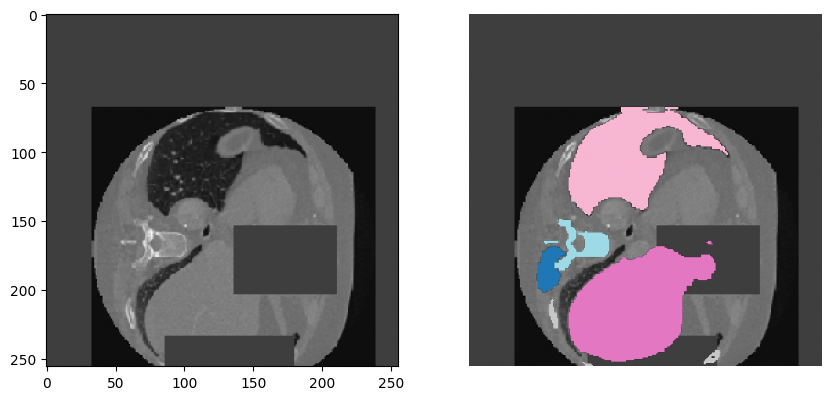

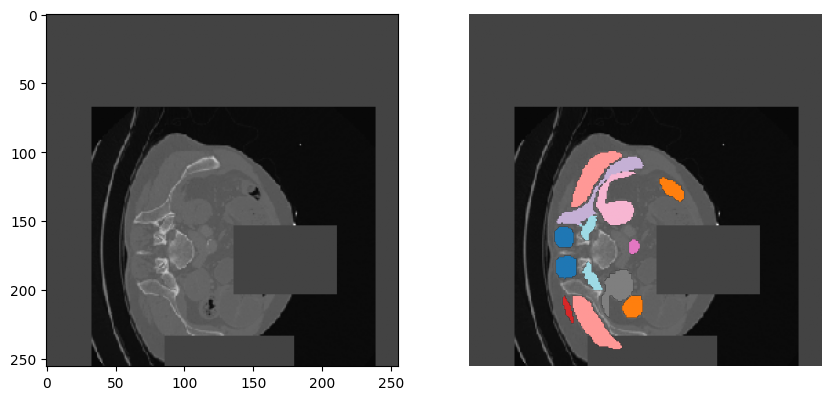

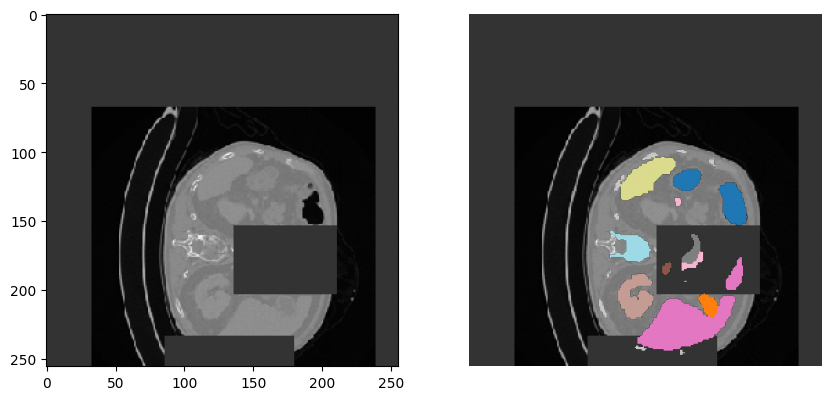

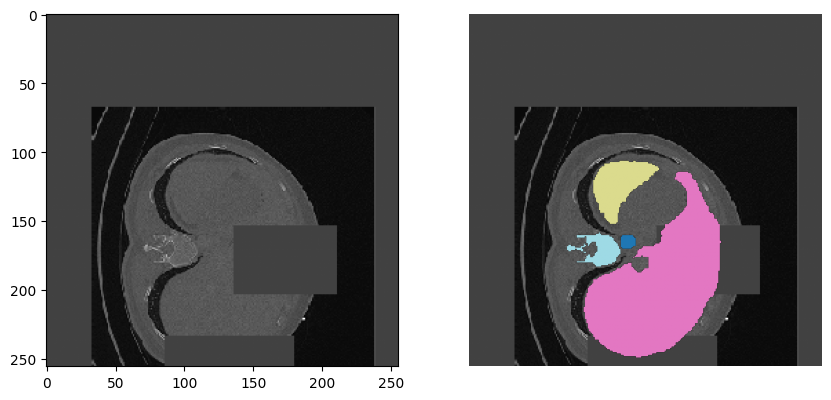

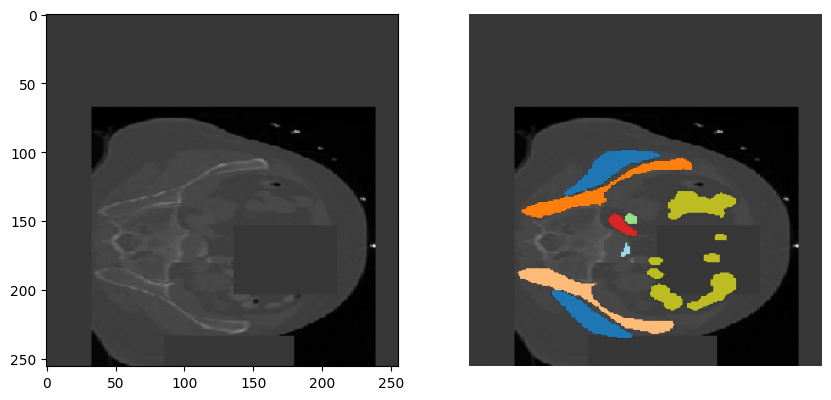

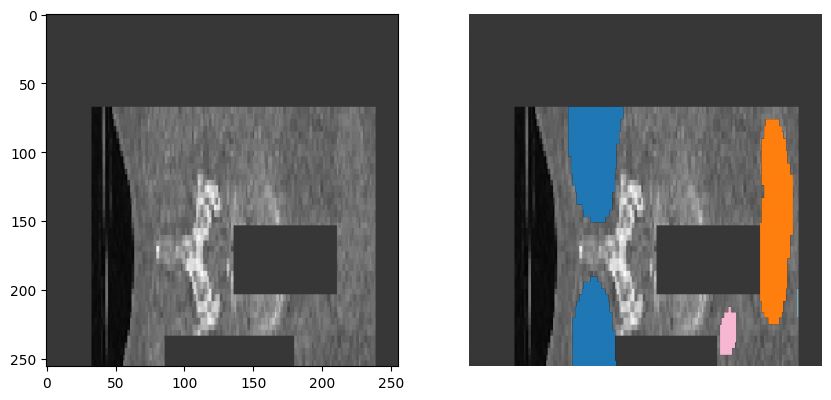

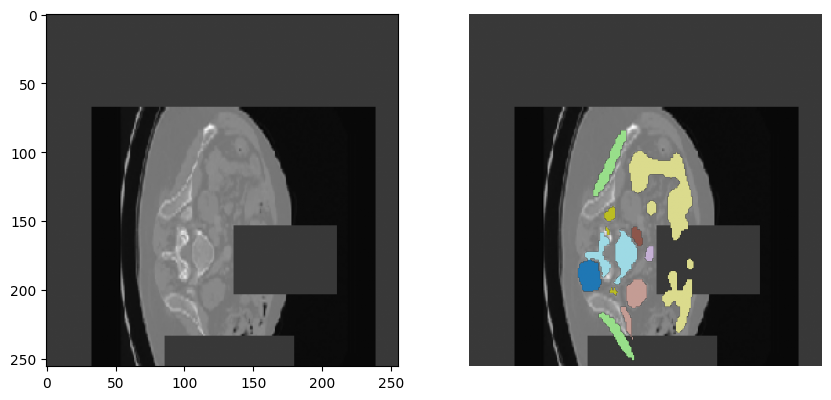

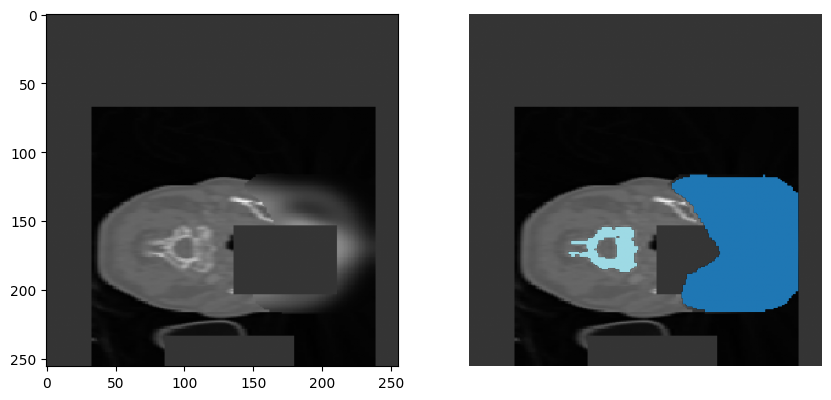

In [4]:
from torchvision import tv_tensors

batch_x_, batch_y_ = dataset_cfg.transform(batch_x, tv_tensors.Mask(batch_y))
for x, y in zip(batch_x_, batch_y_):
    plt_sample(x[0], y)